In [145]:
#pip install torch

In [256]:
import pickle 
import matplotlib.pyplot as plt 
from utils import Generator 
import torch 
import tqdm
from tqdm import *
from train import x
from p1 import *
from p3 import *
import numpy as np
from utils import Discriminator 

In [257]:
parameters = 'p3'

In [276]:
last_muq = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/muq_%s.pkl'%(parameters), 'rb')))[-1]
last_logsigmaq = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/logsigmaq_%s.pkl'%(parameters), 'rb')))[-1]
last_muq_noe = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/muq_noe_%s.pkl'%(parameters), 'rb')))[-1]
last_logsigmaq_noe= torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/logsigmaq_noe_%s.pkl'%(parameters), 'rb')))[-1]


last_muk = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/muk_%s.pkl'%(parameters), 'rb')))[-1]
last_logsigmak = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/logsigmak_%s.pkl'%(parameters), 'rb')))[-1]
last_muk_noe = torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/muk_noe_%s.pkl'%(parameters), 'rb')))[-1]
last_logsigmak_noe= torch.Tensor(pickle.load(open('/home/i.sebag/sync/PWGAN/pickle/logsigmak_noe_%s.pkl'%(parameters), 'rb')))[-1]


In [273]:
D = Discriminator(last_muk, last_logsigmak).o2_polynomial(x).detach().numpy()

(array([ 2.,  2.,  1.,  1.,  2.,  6., 10.,  7., 14., 55.]),
 array([-3.0507839e+00, -2.7457056e+00, -2.4406273e+00, -2.1355491e+00,
        -1.8304707e+00, -1.5253924e+00, -1.2203141e+00, -9.1523582e-01,
        -6.1015749e-01, -3.0507922e-01, -9.1904496e-07], dtype=float32),
 <a list of 10 Patch objects>)

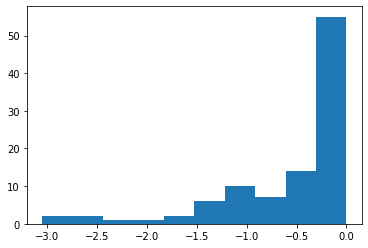

In [274]:
plt.hist(D)

In [275]:
true_logsigma = torch.log(torch.sqrt(torch.var(x))) 
true_mu = torch.mean(x)

In [287]:
sam_gen = []
true_gen = []
sam_gen_noe = []
disc = []
for i in tqdm(range(500)):
    #eps = torch.distributions.Normal(torch.zeros(1), torch.ones(1)).sample()
    eps = torch.rand(1)
    sam_generator = Generator(last_muq, last_logsigmaq, weights).uni_icdf(eps)
    sam_generator_noe = Generator(last_muq_noe, last_logsigmaq_noe, weights).uni_icdf(eps)
    true_generator = Generator(true_logsigma, true_mu, weights).uni_icdf(eps)
    D = Discriminator(last_muk, last_logsigmak).o2_polynomial(x).detach().numpy()
    sam_gen.append(sam_generator.detach().numpy())
    sam_gen_noe.append(sam_generator_noe.detach().numpy())
    true_gen.append(true_generator.detach().numpy())
    

100%|██████████| 500/500 [00:00<00:00, 989.32it/s] 


In [288]:
D

array([-3.7849036e-01, -2.9472039e+00, -2.1163091e-02, -6.4175618e-01,
       -6.4195263e-01, -2.5091538e-01, -2.5928211e-01, -8.7310269e-05,
       -2.7477798e-01, -1.7159122e+00, -7.3450530e-01, -1.3389494e-01,
       -5.8214015e-01, -1.7232456e-03, -1.3032928e+00, -3.8145907e-02,
       -1.3729209e+00, -4.1851565e-01, -2.5867325e-01, -1.1672320e+00,
       -9.6797571e-02, -9.1876847e-01, -7.2733462e-02, -2.6724184e+00,
       -1.0559524e+00, -1.0135965e-01, -4.6520744e-02, -8.0142364e-02,
       -1.4289071e-01, -3.6498347e-01, -9.9442708e-01, -1.0111568e+00,
       -1.4021150e+00, -2.0850849e+00, -2.3154783e+00, -8.0293618e-02,
       -4.0771794e-01, -6.0124964e-02, -5.9927806e-02, -1.4410540e-01,
       -7.5864267e-01, -9.3409693e-04, -3.8371953e-01, -6.4071693e-02,
       -1.2042630e+00, -3.4729249e-03, -5.6066837e-02, -2.9201858e-02,
       -5.1967578e-04, -5.4336414e-02, -3.2909870e-01, -4.0231068e-03,
       -1.5214918e-03, -3.9888674e-01, -1.1463020e+00, -3.0507839e+00,
      

In [289]:
last_logsigmaq

tensor(2.0198)

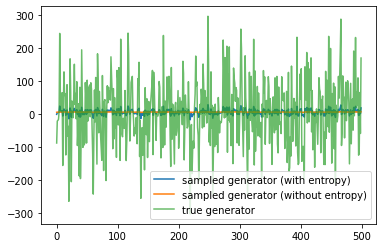

In [290]:
plt.figure()
plt.plot(sam_gen, label = 'sampled generator (with entropy)')
plt.plot(sam_gen_noe, label = 'sampled generator (without entropy)')
plt.plot(true_gen, label = 'true generator ', alpha=0.7)
plt.legend()
plt.show()

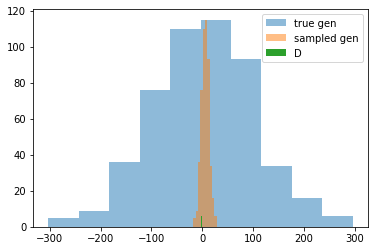

In [291]:
plt.hist(np.hstack(true_gen), alpha=0.5, label = 'true gen')
plt.hist(np.hstack(sam_gen), alpha=0.5, label = 'sampled gen')
plt.hist(D, label = 'D')
plt.legend()

In [205]:

#plot hist (or kernel density plot)
#plot D instead of the true gen with k params 

list

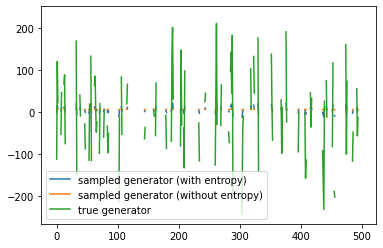

In [178]:
plt.figure()
plt.plot(sam_gen, label = 'sampled generator (with entropy)')
plt.plot(sam_gen_noe, label = 'sampled generator (without entropy)')
plt.plot(true_gen, label = 'true generator ')
plt.legend()
plt.show()